# 01 — Forward Diffusion：把猫变成雪花噪声

> **本 notebook 只讲「加噪」这半边**。02 讲反向训练，03 讲 DDIM 加速，逐个递进。
> 先把加噪搞透，后面的才立得住。

## 一句话直觉

**拿一张图，每一步滴一点点高斯噪声，滴个 1000 步，最后变成纯雪花。**

这件事本身没意义 —— 意义在于：如果你能学会「反向」这个过程（从雪花一步步去噪），
你就学会了**凭空生成图**。

## 为什么要这么绕

直接学「噪声 → 图」太难（一步跨度大，好比让你一笔画出蒙娜丽莎）。
把它拆成 1000 个微小的「去掉一点点噪声」子任务，每个都是个简单回归问题 —— 模型就能学会。

**核心思想：用大量小步骤的简单问题，逼近一个困难问题。**

## 类比

- **物理**：墨滴在水里扩散（forward），要反演就得知道每一瞬间墨团的速度场
- **信息论**：往信号里灌噪声直到信息熵打满（≈ 标准高斯），再学如何从熵中恢复信号
- **日常**：把一本书逐字撕碎成雪花，再训练一个人「倒放」撕书动作 —— 这人就学会了写书


## 📌 符号表（全系列的锚点）

> 忘了随时回来查。**02–05 课共用这一套符号**，不会再换。

| 符号 | 读法 | 是什么 | 取值直觉 |
|------|------|--------|----------|
| $x_0$ | x-零 | 原始干净图像 | 像素通常归一化到 [-1, 1] |
| $x_t$ | x-t | 加了 t 步噪声之后的图 | t 越大越像雪花 |
| $T$ | 大 T | 加噪总步数 | 经典取 1000 |
| $\beta_t$ | beta-t | 第 t 步**新加**的噪声方差 | 很小：1e-4 → 0.02 |
| $\alpha_t = 1-\beta_t$ | alpha-t | 第 t 步**保留**的信号比例（方差意义上） | 非常接近 1，如 0.9999 |
| $\bar\alpha_t = \prod_{s=1}^{t}\alpha_s$ | alpha-bar-t | 累计到第 t 步还**剩多少信号** | 从 ≈1 单调降到 ≈0 |
| $\epsilon$ | epsilon | 标准高斯噪声 $\mathcal{N}(0, I)$ | 就是"雪花"本花 |
| $q(\cdot)$ | q | **前向**加噪分布：手工定死，不训练 | 本课主角 |
| $p_\theta(\cdot)$ | p-theta | **反向**去噪分布：θ 是网络参数，要训练 | 02 课主角 |


## Part 0 — 为什么非要加噪-去噪？

Diffusion 之前，生成模型主要三条路：

| 方法 | 核心思想 | 痛点 |
|------|----------|------|
| **GAN** | 生成器 vs 判别器 | 训练不稳、mode collapse、难 scale |
| **VAE** | encoder → 潜变量 → decoder | 生成**模糊**（ELBO 下界不紧） |
| **Autoregressive**（PixelRNN/CNN） | 一个像素一个像素预测 | **慢到离谱**，高清图跑不动 |

直接学高维图像分布 `p(x)` 本质上太难。

**Diffusion 的 trick**：不直接学 `p(x)`，而是学一串 `p(x_{t-1} | x_t)`，每一步只去掉一点点噪声。
每一步都是一个**简单的条件高斯**，MSE loss 就能拟合。

**关键洞察**：
- 复杂的图像分布 → 通过加噪 → 变成标准高斯（简单且可采样）
- 反过来若能把这个过程倒回去，就能从高斯中"生"出图

这是 Diffusion 对 GAN/VAE 的降维打击：**把难问题拆成无数个简单问题**。


## Part 1 — 前向过程的数学骨架

**马尔科夫链形式**：定义一个 **固定** 的加噪过程（**不含任何可训练参数**，纯手工设计）

$$
q(x_t | x_{t-1}) = \mathcal{N}\!\left(x_t;\; \sqrt{1-\beta_t}\, x_{t-1},\; \beta_t I \right)
$$

> 📖 **读式子**：$\mathcal{N}(\text{生成谁};\ \text{均值},\ \text{方差})$ 一共三个槽位——
> 1. **生成谁**：$x_t$，这一步的输出
> 2. **均值**：$\sqrt{1-\beta_t}\, x_{t-1}$ —— 把上一步的图**整体缩小一点点**（系数 < 1 但非常接近 1）
> 3. **方差**：$\beta_t I$ —— 再**叠一层强度为 $\beta_t$ 的高斯噪声**（各像素独立同分布，所以协方差是 $I$ 的倍数）
>
> 代入真实数值感受一下：$\beta_1 = 10^{-4}$ 时 $\sqrt{1-\beta_1} \approx 0.99995$ —— 图几乎没动，噪声也只有一丁点。
> **单步伤害轻到可以忽略，所以才需要走 T=1000 步才能把图磨成雪花。**

- `β_t ∈ (0, 1)` 是调度超参，通常 **很小**（如 1e-4 ~ 0.02），每步"伤害"很轻
- 做 T=1000 步，整体看就是慢慢把信号稀释、把噪声灌满

**为什么要用 √(1-β_t) 而不是 1？** 保持方差稳定：
- 若 Var(x_0) = 1，则 Var(x_t) 也始终 ≈ 1（方差守恒，信号不会发散）
- 数学上如果 x_{t-1} 单位方差，x_t 的方差 = (1-β_t)·1 + β_t = 1 ✓

### 重参数化：一步到位

如果朴素地跑 T 步，训练效率太低。好在这套递推有闭式解：

$$
x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \epsilon,\qquad \epsilon \sim \mathcal{N}(0, I)
$$

其中：
- α_t = 1 - β_t
- **ᾱ_t = ∏_{s=1}^{t} α_s**（累积乘积，signal 衰减系数）

**训练时的 killer feature**：任意挑一个 t，**一行代码**就能从 x_0 算出 x_t，
不用真的 loop 1000 步。这是 Diffusion 能 scale 的关键。

### 终点条件

当 T 足够大、ᾱ_T → 0 时：

$$
x_T \approx \sqrt{0}\cdot x_0 + \sqrt{1}\cdot \epsilon = \epsilon \sim \mathcal{N}(0, I)
$$

即**信号完全湮灭**，只剩纯高斯噪声。这就是反向采样的起点。


## Part 2 — β schedule 家族地图

β_t 是**设计超参**（不学），但设计得好坏直接影响质量。主流 3 种：

| Schedule | 公式（概念） | 适用 | 出处 |
|----------|--------------|------|------|
| **Linear** | β_t 从 1e-4 线性涨到 0.02 | 简单好懂，高分辨率下够用；**小图（≤64×64）不理想** | DDPM (Ho, 2020) |
| **Cosine** | ᾱ_t = cos²((t/T + s)/(1+s) · π/2) | **中间 t 信噪比更合理**；实证在 CIFAR-10 (32×32) 和 ImageNet **64×64** 上提升 | Improved DDPM (Nichol & Dhariwal, 2021) |
| **Sigmoid / EDM** | β_t 形如 sigmoid，或用 σ 参数化 | 高分辨率 / Karras-style | EDM (Karras, 2022) |

**Linear 的锅**：ᾱ_t 掉得偏快（t≈260 就信噪各半，t≈500 只剩约 8% 信号），
forward 的**后小半段几乎泡在纯噪声区**，这些时间步对样本质量贡献很小
（Improved DDPM 实测：跳过反向过程开头 20% 的步数，FID 几乎不掉）。
这个问题**在小图（32×32 / 64×64）上尤其明显**——小图像素冗余少，同样的噪声破坏得更彻底；
高分辨率图冗余大，linear 反而还能凑合。

**Cosine 的解药**：不调 β，直接把 ᾱ_t 的下降曲线设计得更"温柔"（中段近似匀速、两端平缓），
保证中间 t 的信噪比是有意义的。这是 OpenAI 在 Improved DDPM 里的一大 trick。

> 顺带纠正一个坊间流传的说法："cosine 是给高分辨率用的" —— 恰好说反了。
> 论文实证是小图；后续工作（simple diffusion 等）反而发现分辨率**越高**越要把 schedule
> 往"加更多噪"的方向 shift。正确记法：**cosine 修的是 linear 在小图上加噪过快的问题**。

---

### 本 notebook 的任务
1. 实现 Linear + Cosine 两种 schedule，对比曲线
2. 用**朴素循环**跑一次 forward，验证自己对马尔科夫链的理解
3. 用**重参数化**一步到位，验证两者分布一致
4. 可视化不同 t 时刻的加噪效果（看你的图怎么"消失"）
5. 算 SNR、方差守恒，验证理论性质
6. 封装成 `ForwardDiffusion` 类


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

T = 1000        # 总步数
IMG_SIZE = 32   # 测试图尺寸
device = 'cpu'  # CPU 就够跑

print(f'T={T}, image size={IMG_SIZE}x{IMG_SIZE}, device={device}')


T=1000, image size=32x32, device=cpu


## Step 1 — Linear β Schedule

DDPM 原始设定：
- β_1 = 1e-4
- β_T = 0.02
- 中间线性插值

基于 β_t 再推出：
- α_t = 1 - β_t
- ᾱ_t = cumprod(α_t)
- √ᾱ_t 和 √(1-ᾱ_t) 是重参数化的两个核心系数


In [2]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas = torch.linspace(beta_start, beta_end, T)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_bars

betas_lin, alphas_lin, abar_lin = linear_beta_schedule(T)

print(f'β_1 = {betas_lin[0]:.5f},  β_T = {betas_lin[-1]:.5f}')
print(f'ᾱ_1 = {abar_lin[0]:.5f}  (基本 = 1，信号完整)')
print(f'ᾱ_T = {abar_lin[-1]:.6f} (≈ 0，信号完全湮灭)')
print(f'√ᾱ_T = {abar_lin[-1].sqrt():.6f} → x_T ≈ 1·ε，纯高斯')


β_1 = 0.00010,  β_T = 0.02000
ᾱ_1 = 0.99990  (基本 = 1，信号完整)
ᾱ_T = 0.000040 (≈ 0，信号完全湮灭)
√ᾱ_T = 0.006353 → x_T ≈ 1·ε，纯高斯


In [ ]:
# 画 schedule 曲线
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
t_axis = np.arange(T)

axes[0].plot(t_axis, betas_lin, color='tab:red')
axes[0].set_title('β_t (noise injection rate)')
axes[0].set_xlabel('t'); axes[0].set_ylabel('β')

axes[1].plot(t_axis, alphas_lin, color='tab:blue')
axes[1].set_title('α_t = 1 - β_t')
axes[1].set_xlabel('t')

axes[2].plot(t_axis, abar_lin, color='tab:green', label='ᾱ_t (signal retained)')
axes[2].plot(t_axis, 1 - abar_lin, color='tab:orange', label='1-ᾱ_t (noise accumulated)')
axes[2].set_title('ᾱ_t vs 1-ᾱ_t')
axes[2].set_xlabel('t'); axes[2].legend()

plt.tight_layout(); plt.show()
print('👉 ᾱ_t 掉得不算慢：t=100 还剩 ~90% 信号，但 t≈260 就信噪各半，t≈500 只剩 ~8%——')
print('   后小半段基本泡在纯噪声区，这是 Improved DDPM 吐槽 linear 的点（小图 32×32/64×64 上尤其浪费）')


## Step 2 — Cosine Schedule（Improved DDPM）

换个思路：**不再设计"每步加多少噪"（β_t），而是直接设计"还剩多少信号"（ᾱ_t）的下降曲线**，
让它沿一条余弦平方缓缓滑下去：

$$
\bar\alpha_t = \frac{f(t)}{f(0)},\qquad f(t) = \cos^2\!\left(\frac{t/T + s}{1 + s}\cdot\frac{\pi}{2}\right)
$$

> 📖 **读式子**：
> - 代入 $t=0$：$f(0)/f(0) = 1$ —— 信号完整 ✓
> - 代入 $t=T$：$\cos(\approx\pi/2)^2 \approx 0$ —— 信号湮灭 ✓
> - 中间是一条前缓、中匀、后缓的 S 形下降
>
> $s \approx 0.008$ 是个小偏移：没有它，$t=0$ 附近反推出来的 $\beta_t$ 会小到几乎为 0——
> 开头几步噪声太微弱，网络反而很难学会准确预测 $\epsilon$（Improved DDPM 原文给的理由）。

β_t 再从 ᾱ_t 反推：

$$
\beta_t = 1 - \frac{\bar\alpha_t}{\bar\alpha_{t-1}}
$$

并 clip 到 `[0, 0.999]`，防止接近 t=T 时 β 过大引起数值奇异。


/tmp/ipykernel_1075282/111728615.py:29: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1075282/111728615.py:29: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1075282/111728615.py:29: UserWarning: Glyph 26356 (\N{CJK UNIFIED IDEOGRAPH-66F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1075282/111728615.py:29: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1075282/111728615.py:29: UserWarning: Glyph 26580 (\N{CJK UNIFIED IDEOGRAPH-67D4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<local-env>/miniforge3/envs/llm-learning/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from fo

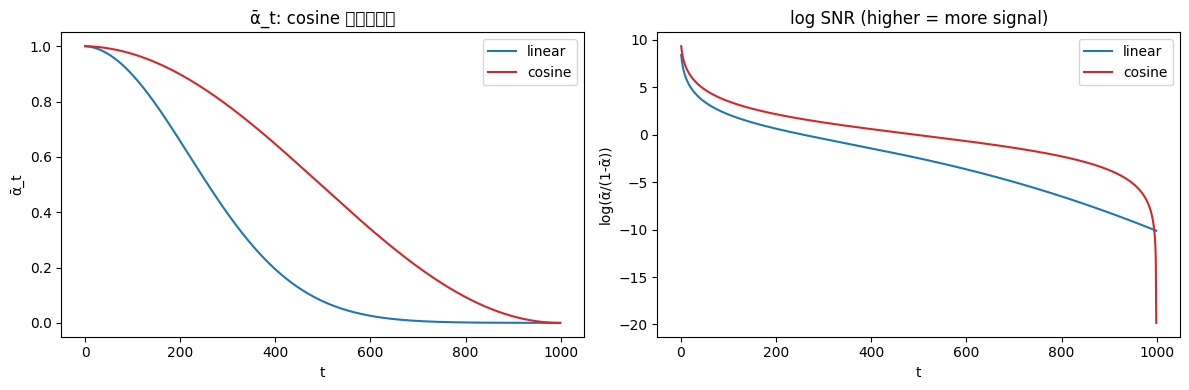

👉 在中间 t（如 400-800），cosine 保留了显著更多的信号 → 反向模型有更有意义的监督信号


In [4]:
def cosine_beta_schedule(T, s=0.008):
    steps = T + 1
    t = torch.linspace(0, T, steps) / T
    f = torch.cos((t + s) / (1 + s) * torch.pi / 2) ** 2
    alpha_bars = f / f[0]
    betas = 1 - alpha_bars[1:] / alpha_bars[:-1]
    betas = betas.clamp(0, 0.999)
    alphas = 1.0 - betas
    alpha_bars_final = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_bars_final

betas_cos, alphas_cos, abar_cos = cosine_beta_schedule(T)

# 对比
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_axis, abar_lin, label='linear', color='tab:blue')
axes[0].plot(t_axis, abar_cos, label='cosine', color='tab:red')
axes[0].set_title('ᾱ_t: cosine 下降更温柔')
axes[0].set_xlabel('t'); axes[0].set_ylabel('ᾱ_t'); axes[0].legend()

# SNR 对比（log 尺度看中间 t 差异）
snr_lin = abar_lin / (1 - abar_lin + 1e-9)
snr_cos = abar_cos / (1 - abar_cos + 1e-9)
axes[1].plot(t_axis[1:], snr_lin[1:].log(), label='linear', color='tab:blue')
axes[1].plot(t_axis[1:], snr_cos[1:].log(), label='cosine', color='tab:red')
axes[1].set_title('log SNR (higher = more signal)')
axes[1].set_xlabel('t'); axes[1].set_ylabel('log(ᾱ/(1-ᾱ))'); axes[1].legend()

plt.tight_layout(); plt.show()
print('👉 在中间 t（如 400-800），cosine 保留了显著更多的信号 → 反向模型有更有意义的监督信号')


## Step 3 — 朴素循环：真的跑 T 步马尔科夫链

**为了理解** forward process，先用朴素方法跑一遍：

$$
x_t = \sqrt{1-\beta_t}\, x_{t-1} + \sqrt{\beta_t}\, \epsilon_t
$$

每步单独采一个新的 ε_t（独立同分布）。跑 T=1000 步得到最终的 x_T。


In [5]:
def forward_naive(x0, betas):
    '''逐步加噪，记录每一步的 x_t'''
    T = len(betas)
    xs = [x0]
    x_prev = x0
    for t in range(T):
        beta_t = betas[t]
        eps = torch.randn_like(x_prev)
        x_t = torch.sqrt(1 - beta_t) * x_prev + torch.sqrt(beta_t) * eps
        xs.append(x_t)
        x_prev = x_t
    return torch.stack(xs)  # (T+1, ...)

# 先构造一个"已知分布"的 x_0：单位方差标准正态本身，看 x_T 是否保持单位方差
x0 = torch.randn(10000)
xs_lin = forward_naive(x0, betas_lin)
print(f'x_0 均值: {x0.mean():.4f}, 方差: {x0.var():.4f}')
print(f'x_T 均值: {xs_lin[-1].mean():.4f}, 方差: {xs_lin[-1].var():.4f}')
print('👉 若方差守恒，两者都应 ≈ 1 —— 这就是为什么前向用 √(1-β_t) 系数')


x_0 均值: -0.0107, 方差: 1.0039
x_T 均值: 0.0045, 方差: 1.0246
👉 若方差守恒，两者都应 ≈ 1 —— 这就是为什么前向用 √(1-β_t) 系数


## Step 4 — 重参数化：一步到位

关键公式：

$$
\boxed{\; x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \epsilon\;}
$$

> 📖 **读式子**：
> - 两个系数**平方和恒为 1**：$(\sqrt{\bar\alpha_t})^2 + (\sqrt{1-\bar\alpha_t})^2 = 1$ ——
>   信号占多少方差、噪声就正好补多少，方差永远守恒
> - 极端检查 $t=1$：$\bar\alpha_1 = 0.9999$，$x_1 \approx x_0$，几乎没动 ✓
> - 极端检查 $t=T$：$\bar\alpha_T \approx 4\times 10^{-5}$，$x_T \approx \epsilon$，纯噪声 ✓

一个 ε ~ N(0, I) 采样就够了，**不用真的跑 T 步**。
为什么能这样：两个独立高斯相加还是高斯，方差线性相加 —— 马尔科夫链的每步累加效果等价于一次大跳。
（逐步推导见文末面试题 Q2，核心工具就这一个。）

训练时随机 t，随机 ε，一行代码算 x_t，喂给网络去预测 ε。这是 Diffusion 能在大数据上 scale 的底座。


In [6]:
def q_sample(x0, t, alpha_bars, noise=None):
    '''一步到位采样 x_t ~ q(x_t | x_0)

    x0: (B, ...) 原图
    t:  (B,) int tensor, 每个样本自己的时间步
    '''
    if noise is None:
        noise = torch.randn_like(x0)
    abar_t = alpha_bars[t]
    while abar_t.dim() < x0.dim():
        abar_t = abar_t.unsqueeze(-1)
    return torch.sqrt(abar_t) * x0 + torch.sqrt(1 - abar_t) * noise

# 验证：和 naive 跑出来的分布是否一致（任取一个 t）
t_test = 500
x0_big = torch.randn(5000)
# naive 方法跑到 t=500
xs_naive = forward_naive(x0_big, betas_lin[:t_test])
x_t_naive = xs_naive[-1]
# reparam 直接跳到 t=500
t_idx = torch.full((5000,), t_test - 1, dtype=torch.long)
x_t_repar = q_sample(x0_big, t_idx, abar_lin)

print(f'同一个 t=500：')
print(f'  naive 均值 {x_t_naive.mean():+.4f} 方差 {x_t_naive.var():.4f}')
print(f'  reparam 均值 {x_t_repar.mean():+.4f} 方差 {x_t_repar.var():.4f}')
print('👉 两者分布统计量一致（个体不同是因为随机种子/ε 不同，但统计意义上等价）')


同一个 t=500：
  naive 均值 -0.0079 方差 0.9773
  reparam 均值 +0.0048 方差 1.0176
👉 两者分布统计量一致（个体不同是因为随机种子/ε 不同，但统计意义上等价）


## Step 5 — 可视化：看你的图怎么"消失"

造一张 32×32 的测试图（"笑脸"图案，无外部依赖），
用 linear 和 cosine 两种 schedule 各画出 t = 0, 50, 100, 200, 400, 600, 800, 999 八个时刻。


In [ ]:
def make_smiley(size=32):
    '''纯 numpy 画一个极简笑脸 size×size 灰度图，取值 [-1, 1]'''
    img = np.zeros((size, size), dtype=np.float32)
    yy, xx = np.mgrid[0:size, 0:size]
    cx, cy = size / 2, size / 2
    # 脸盘
    face = ((xx - cx) ** 2 + (yy - cy) ** 2) <= (size * 0.42) ** 2
    img[face] = 0.6
    # 眼睛
    for ex_off in [-size * 0.15, size * 0.15]:
        eye = ((xx - (cx + ex_off)) ** 2 + (yy - (cy - size * 0.1)) ** 2) <= (size * 0.06) ** 2
        img[eye] = -0.8
    # 嘴（半月）
    mouth_upper = ((xx - cx) ** 2 + (yy - (cy + size * 0.05)) ** 2) <= (size * 0.22) ** 2
    mouth_lower = ((xx - cx) ** 2 + (yy - (cy + size * 0.05)) ** 2) <= (size * 0.18) ** 2
    img[mouth_upper & ~mouth_lower & (yy > cy + size * 0.05)] = -0.8
    return img

x0_img = torch.from_numpy(make_smiley(IMG_SIZE)).unsqueeze(0)  # (1, 32, 32)
print('x0 shape:', x0_img.shape, '| min', x0_img.min().item(), 'max', x0_img.max().item())

# 固定 ε 让可视化更稳定
fixed_noise = torch.randn_like(x0_img)

t_showcase = [0, 50, 100, 200, 400, 600, 800, 999]
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i, t in enumerate(t_showcase):
    if t == 0:
        # t=0 就是原图本身，不加噪
        x_t_lin = x_t_cos = x0_img
    else:
        t_idx = torch.tensor([t - 1])  # 第 t 步对应数组索引 t-1
        x_t_lin = q_sample(x0_img, t_idx, abar_lin, noise=fixed_noise)
        x_t_cos = q_sample(x0_img, t_idx, abar_cos, noise=fixed_noise)

    axes[0, i].imshow(x_t_lin[0], cmap='gray', vmin=-2, vmax=2)
    axes[0, i].set_title(f't={t}', fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_t_cos[0], cmap='gray', vmin=-2, vmax=2)
    axes[1, i].axis('off')

# axis('off') 会把 ylabel 一起隐藏，行标签只能用 fig.text 画
fig.text(0.02, 0.72, 'Linear', fontsize=12, rotation=90)
fig.text(0.02, 0.28, 'Cosine', fontsize=12, rotation=90)
plt.tight_layout(); plt.show()
print('👉 Cosine 行（下）t=600 还能看出脸的轮廓（ᾱ≈0.34）；'
      'Linear 行（上）t=400 只剩隐约影子（ᾱ≈0.20），t≥600 基本纯噪声（ᾱ≈0.03）')


## Step 6 — 性质验证：SNR / 均值 / 方差

三个必考事实：

1. **SNR(t) = ᾱ_t / (1 - ᾱ_t)**（signal-to-noise ratio）
   - SNR(0) = ∞，SNR(T) ≈ 0
   - Cosine 在中间 t 维持更好的 SNR
2. **Var(x_t) = ᾱ_t·Var(x_0) + (1-ᾱ_t)·1**
   - 若 Var(x_0) = 1，则始终 Var(x_t) = 1 —— 方差守恒
3. **E[x_t] = √ᾱ_t · E[x_0]**
   - t 越大，均值被压越小，越接近 0（高斯中心）


In [8]:
# 1. 方差守恒实验
x0_unit = torch.randn(50000)  # 单位方差
variances = []
for t in [1, 10, 100, 500, 999]:
    t_idx = torch.full((50000,), t - 1, dtype=torch.long)
    x_t = q_sample(x0_unit, t_idx, abar_lin)
    variances.append((t, x_t.var().item()))
print('Linear schedule 方差守恒检查 (x_0 单位方差):')
for t, v in variances:
    print(f'  t={t:4d}  Var(x_t) = {v:.4f}')
print('👉 全都 ≈ 1，方差严格守恒 ✓')
print()

# 2. x_T 分布接近 N(0,1) 吗？
t_idx = torch.full((50000,), T - 1, dtype=torch.long)
x_T = q_sample(x0_unit, t_idx, abar_lin)
print(f'x_T 均值: {x_T.mean():+.4f} (应 ≈ 0)')
print(f'x_T 方差: {x_T.var():.4f} (应 ≈ 1)')
print(f'x_T 偏度: {((x_T - x_T.mean()) ** 3).mean() / x_T.std() ** 3:+.4f} (应 ≈ 0)')
print(f'x_T 峰度: {((x_T - x_T.mean()) ** 4).mean() / x_T.std() ** 4:.4f} (高斯 = 3)')


Linear schedule 方差守恒检查 (x_0 单位方差):
  t=   1  Var(x_t) = 1.0169
  t=  10  Var(x_t) = 1.0175
  t= 100  Var(x_t) = 1.0161
  t= 500  Var(x_t) = 1.0028
  t= 999  Var(x_t) = 1.0057
👉 全都 ≈ 1，方差严格守恒 ✓

x_T 均值: -0.0022 (应 ≈ 0)
x_T 方差: 1.0110 (应 ≈ 1)
x_T 偏度: +0.0160 (应 ≈ 0)
x_T 峰度: 3.0251 (高斯 = 3)


In [ ]:
# 3. SNR 曲线可视化
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_axis[1:], (abar_lin[1:] / (1 - abar_lin[1:])).log(), label='linear', color='tab:blue')
ax.plot(t_axis[1:], (abar_cos[1:] / (1 - abar_cos[1:])).log(), label='cosine', color='tab:red')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5, label='SNR=1 (信噪等)')
ax.set_title('log SNR 随 t 的衰减')
ax.set_xlabel('t'); ax.set_ylabel('log SNR')
ax.legend(); plt.tight_layout(); plt.show()

# 读几个关键点
for name, abar in [('linear', abar_lin), ('cosine', abar_cos)]:
    t_half = ((abar / (1 - abar) - 1).abs()).argmin().item() + 1
    print(f'{name}: SNR=1 发生在 t ≈ {t_half:4d}  (信号与噪声等强)')


## Step 7 — 封装 `ForwardDiffusion` 类

把上面的东西打包成一个可复用对象，后面的 notebook 会持续用：


In [9]:
class ForwardDiffusion:
    '''Forward (noising) process for DDPM.

    用法:
        fd = ForwardDiffusion(T=1000, schedule='cosine')
        x_t, noise = fd.q_sample(x0, t)   # 返回加噪图和用到的噪声
    '''
    def __init__(self, T=1000, schedule='linear', **kwargs):
        self.T = T
        if schedule == 'linear':
            self.betas, self.alphas, self.alpha_bars = linear_beta_schedule(T, **kwargs)
        elif schedule == 'cosine':
            self.betas, self.alphas, self.alpha_bars = cosine_beta_schedule(T, **kwargs)
        else:
            raise ValueError(schedule)
        self.sqrt_abar = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_abar = torch.sqrt(1 - self.alpha_bars)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sa = self.sqrt_abar[t]
        sma = self.sqrt_one_minus_abar[t]
        while sa.dim() < x0.dim():
            sa = sa.unsqueeze(-1); sma = sma.unsqueeze(-1)
        return sa * x0 + sma * noise, noise

    def snr(self, t):
        abar_t = self.alpha_bars[t]
        return abar_t / (1 - abar_t + 1e-9)

# 快速自测
fd = ForwardDiffusion(T=1000, schedule='cosine')
x0 = torch.randn(4, 1, 32, 32)
t = torch.randint(0, 1000, (4,))
x_t, noise = fd.q_sample(x0, t)
print('x_t shape:', x_t.shape, '| noise shape:', noise.shape)
print('t =', t.tolist())
print('SNR =', [f'{fd.snr(ti).item():.3f}' for ti in t])


x_t shape: torch.Size([4, 1, 32, 32]) | noise shape: torch.Size([4, 1, 32, 32])
t = [707, 271, 154, 118]
SNR = ['0.239', '4.603', '14.873', '24.968']


## 面试 6 连问（自己先答，再展开参考答案）

1. **为什么 forward process 要用 √(1-β_t) 这个系数？用 1 行不行？**
2. **重参数化技巧 `x_t = √ᾱ·x_0 + √(1-ᾱ)·ε` 是怎么从马尔科夫链推出来的？**
3. **linear schedule 在什么分辨率上拉胯？cosine 解决了什么？**
4. **T 取多大合适？T 太小 / T 太大分别会怎样？**
5. **β_t 是可训练的吗？Diffusion 的「学」到底学什么？**
6. **前向过程是否包含「信息」？为什么训练数据 x_0 不出现在模型输入里？**

---

### 参考答案（展开）

<details>
<summary>Q1：为什么是 √(1-β_t) 不是 1</summary>

为了 **方差守恒**。若 x_{t-1} 是单位方差，则

```
Var(x_t) = (1-β_t)·Var(x_{t-1}) + β_t·Var(ε) = (1-β_t) + β_t = 1
```

若系数用 1，Var(x_t) = 1 + β_t 会不断累加发散，x_T 方差会爆炸到 O(T·β)。
守恒让训练稳定、预测目标尺度一致、能直接用标准高斯做采样起点。
</details>

<details>
<summary>Q2：重参数化的推导</summary>

起点是递推 `x_t = √α_t·x_{t-1} + √(1-α_t)·ε_t`。
**核心工具只有一个：独立高斯相加还是高斯，方差直接相加。** 下面三步走：

**第 1 步 —— 展开一层**（把 x_{t-1} 用它自己的递推式替换掉，纯代数代入）：

```
x_t = √(α_t·α_{t-1})·x_{t-2} + √α_t·√(1-α_{t-1})·ε_{t-1} + √(1-α_t)·ε_t
```

**第 2 步 —— 合并两个噪声项**（ε_{t-1} 与 ε_t 相互独立，加起来还是一个零均值高斯，
方差 = 两项方差之和）：

```
α_t·(1-α_{t-1}) + (1-α_t) = 1 - α_t·α_{t-1}
```

于是两项噪声合写成一个 √(1-α_t·α_{t-1})·ε̄（ε̄ 是新的标准高斯）。
注意规律：**信号系数平方 + 噪声方差 = 1**，展开多少层都成立。

**第 3 步 —— 一路归纳到 x_0**（每展开一层，信号系数就多乘一个 α；
噪声方差始终是"1 − 信号系数平方"）：

```
x_t = √(∏α_s)·x_0 + √(1-∏α_s)·ε = √ᾱ_t·x_0 + √(1-ᾱ_t)·ε
```
</details>

<details>
<summary>Q3：Linear vs Cosine 的锅</summary>

Improved DDPM 的实测结论和坊间传言相反：**linear 在高分辨率上其实够用，
拉胯的是小图（32×32 / 64×64）**。

原因：linear 让 ᾱ_t 掉得偏快（t≈260 信噪各半，t≈500 只剩约 8% 信号，t>700 才算真正"几乎纯噪声"），
forward 后小半段的时间步对样本质量贡献很小（论文实测：跳过反向过程开头 20% 的步数 FID 几乎不掉）。
小图像素冗余少，同样的噪声破坏得更彻底，所以更遭殃。

cosine 直接设计 ᾱ_t 曲线，下降是 **S 形** —— 前期慢、中期匀、末期缓，
保证中间 t 仍有可辨识的信号（t=500 时 cosine ᾱ≈0.49 vs linear ≈0.08），
监督信号质量整体更好。实证在 CIFAR-10 和 ImageNet 64×64 上提升。
</details>

<details>
<summary>Q4：T 选多少</summary>

- T 太小（比如 50）：每一步 β_t 需要很大才能最终到噪声，单步去噪任务太难，反向预测误差大
- T 太大（比如 10000）：每步很轻，训练容易，**但采样要 loop 10000 次，推理慢到不可用**
- 经典值 **T=1000**（DDPM），加上 DDIM/Flow 后推理只跑 20~50 步

这其实也是 Diffusion → Flow Matching 演进的驱动力：把 T 变小、把路径变直。
</details>

<details>
<summary>Q5：β_t 可训练吗？学什么？</summary>

β_t **固定**，不是可学参数（Improved DDPM 里把 Σ 做了学习化，但 β 还是固定）。

**模型学的是反向过程**：给定 x_t，预测去掉多少噪声。三种等价表述（互相可线性换算）：
- ε-prediction：直接预测加进去的噪声 ε（DDPM 原版）
- score-prediction：预测 ∇_x log p(x_t)（SDE 视角）
- v-prediction：预测 v = √ᾱ_t·ε − √(1-ᾱ_t)·x_0，即 ε 和 x_0 的线性组合（progressive distillation 提出）

前向是**手工设计的退化过程**，反向才是学的那部分。
</details>

<details>
<summary>Q6：x_0 为什么不出现在输入里</summary>

因为训练时 x_0 **只是用来生成监督样本**，推理时我们要的是**凭空生成**（没有 x_0）。

训练阶段：采一个 x_0，采一个 t，采一个 ε，算 x_t，喂给网络预测 ε。
推理阶段：从纯噪声 x_T 开始，一步步用网络预测的 ε 反推 x_{t-1}，直到 x_0。

forward 过程只是「出题机」：造出 (x_t, t, ε) 这对样本让网络学。
forward 的参数完全在网络训练完成后就用不上了（只用到 ᾱ_t 这些常量做反向采样）。
</details>

---

**完成标志** — 如果你能答出上面 6 题，恭喜你 forward process 已经吃透 ✓

**下一站 →** `02_ddpm_backward.ipynb`：训练一个小网络预测 ε，跑 MNIST 级任务，可视化去噪轨迹。
